In [29]:
import os
import sys

import numpy as np
import pandas as pd

import warnings

warnings.filterwarnings("ignore")
sys.path.append(os.path.abspath(os.path.join("modelling", '../..')))

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

from sklearn.decomposition import PCA, NMF, KernelPCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [30]:
SEED = 42
PLOT_DPI = 100

DATA_FILE = "../../datasets/Skoltech_Anomaly_Benchmark/preprocessed_skab_dataset_set2.csv"

In [31]:
dataframe = pd.read_csv(DATA_FILE)
dataframe.set_index(pd.to_datetime(dataframe.datetime), drop=True, inplace=True)
dataframe.drop(columns=["datetime"], inplace=True)
dataframe.head()

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,AccelerometerRMS_Fluctuation,Temperature_Fluctuation,Thermocouple_Fluctuation,Volume Flow RateRMS_Fluctuation,Hydraulic_Power_Fluctuation,Electrical_Power_Fluctuation,anomaly,description
datetime,,,,,,,,,,,,,,,,,,,,,
2020-02-08 13:30:47,0.202394,0.275154,2.16975,1.402774,90.6454,26.8508,238.852,122.664,110.082728,0.011436,...,0.205773,0.010205,0.000339,0.06556,0.004268,0.23928,42.844684,64.762931,0.0,No Anomaly
2020-02-08 13:30:48,0.203153,0.277857,2.07999,0.746920,90.7978,26.8639,227.943,122.338,109.588508,0.006105,...,0.225304,0.005911,0.000339,0.06556,0.004268,0.23928,42.844684,64.762931,0.0,No Anomaly
2020-02-08 13:30:49,0.203153,0.277857,2.07999,0.746920,90.7978,26.8639,227.943,122.338,109.588508,0.006105,...,0.225304,0.005911,0.000339,0.06556,0.004268,0.23928,42.844684,64.762931,0.0,No Anomaly
2020-02-08 13:30:50,0.202054,0.275790,2.52577,1.402774,90.7730,26.8603,223.486,121.338,88.482324,0.011561,...,0.189188,0.009251,0.000339,0.06556,0.004268,0.23928,42.844684,64.762931,0.0,No Anomaly
2020-02-08 13:30:51,0.203595,0.278101,2.49742,1.074847,90.8424,26.8616,244.904,121.664,98.062801,0.008835,...,0.174736,0.006552,0.000339,0.06556,0.004268,0.23928,42.844684,64.762931,0.0,No Anomaly


In [32]:
dataframe_X = dataframe.drop(columns=["anomaly", "description"])
dataframe_y = dataframe[["anomaly"]]

dataframe_X.head()

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Vibration_Intensity_Ratio,AccelerometerRMS_pu_Pressure,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,AccelerometerRMS_Fluctuation,Temperature_Fluctuation,Thermocouple_Fluctuation,Volume Flow RateRMS_Fluctuation,Hydraulic_Power_Fluctuation,Electrical_Power_Fluctuation
datetime,,,,,,,,,,,,,,,,,,,,,
2020-02-08 13:30:47,0.202394,0.275154,2.16975,1.402774,90.6454,26.8508,238.852,122.664,110.082728,0.011436,...,0.735566,0.000454,0.205773,0.010205,0.000339,0.06556,0.004268,0.23928,42.844684,64.762931
2020-02-08 13:30:48,0.203153,0.277857,2.07999,0.746920,90.7978,26.8639,227.943,122.338,109.588508,0.006105,...,0.731142,0.000461,0.225304,0.005911,0.000339,0.06556,0.004268,0.23928,42.844684,64.762931
2020-02-08 13:30:49,0.203153,0.277857,2.07999,0.746920,90.7978,26.8639,227.943,122.338,109.588508,0.006105,...,0.731142,0.000461,0.225304,0.005911,0.000339,0.06556,0.004268,0.23928,42.844684,64.762931
2020-02-08 13:30:50,0.202054,0.275790,2.52577,1.402774,90.7730,26.8603,223.486,121.338,88.482324,0.011561,...,0.732637,0.000459,0.189188,0.009251,0.000339,0.06556,0.004268,0.23928,42.844684,64.762931
2020-02-08 13:30:51,0.203595,0.278101,2.49742,1.074847,90.8424,26.8616,244.904,121.664,98.062801,0.008835,...,0.732090,0.000465,0.174736,0.006552,0.000339,0.06556,0.004268,0.23928,42.844684,64.762931


In [33]:
def get_cluster_centers(df):
    """
    Get initial cluster centers for KMeans clustering.
    """
    init_center = list()
    for idx in df.anomaly.unique():
        tmp = df.iloc[np.where(df.anomaly == idx)]
        tmp.drop(["anomaly", "description"], axis=1, inplace=True)
        tmp_mean = tmp.mean(axis=0)
        init_center.append([val.item() for val in tmp_mean.values])
    init_center = np.array(init_center)
    return init_center

In [34]:
def get_predictions(df, centers):
    prediction = list()
    tmp = df.drop(columns=["anomaly", "description"]).to_numpy()
    for val in tmp:
        distances = np.linalg.norm(centers - val, axis=1)
        prediction.append(float(np.argmin(distances)))

    tmp = df.copy()
    tmp["prediction"] = prediction
    return tmp

In [35]:
def get_confusion_matrix(df, columns, title="Confusion Matrix"):
    plt.figure(figsize=(20, 6), dpi=PLOT_DPI)

    cf = confusion_matrix(df.anomaly.values, df.prediction.values)

    summ = cf.sum(axis=1).reshape(1, cf.shape[0])
    summ = np.vstack([summ for _ in range(summ.shape[1])])

    sns.heatmap(np.around(cf / summ.T, 3), annot=True, xticklabels=columns, yticklabels=columns)

    accuracy  = np.trace(cf) / float(np.sum(cf))
    precision = np.diag(cf) / np.sum(cf, axis=0)
    recall    = np.diag(cf) / np.sum(cf, axis=1)
    f1_score = 2 * (precision * recall) / (precision + recall)

    # print(f"Accuracy: {accuracy:.4f}")
    # print(f"F1 Score: {}")
    # print(f"Diagonal: {np.diag(cf)}", np.sum(cf, axis=0))
    # print(f"Precision: {precision}")
    # print(f"Diagonal: {np.diag(cf)}", np.sum(cf, axis=1))
    # print(f"Recall: {recall}")

    precision = np.around(np.mean(precision), 4)
    recall = np.around(np.mean(recall), 4)
    f1_score = np.around(np.mean(f1_score), 4)
    
    plt.title(title)
    plt.ylabel("True label")
    plt.xlabel(f"Predicted label \n Accuracy = {accuracy:0.4f} \n Precision = {precision} \n Recall = {recall} \n F1 Score = {f1_score}")

    plt.show()

In [37]:
combined = zip(dataframe.anomaly.values, dataframe.description.values)
sorted_pairs = sorted(combined, key=lambda pair: pair[0])

anomaly_ids = dict()
for i in sorted_pairs:
    anomaly_ids[i[0]] = i[1]

anomaly_names = [val for key, val in anomaly_ids.items()]

## Original Data

In [38]:
dataframe_X_og = dataframe_X.iloc[:, :8]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(dataframe_X_og.to_numpy())

dataframe_X_og = pd.DataFrame(X_scaled, columns=dataframe_X_og.columns)
dataframe_X_og = dataframe_X_og.assign(anomaly=dataframe.anomaly.values, description=dataframe.description.values)
dataframe_X_og.head()

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,anomaly,description
0,0.577937,0.779183,0.645772,1.189504,1.214184,0.127393,0.847179,1.044168,0.0,No Anomaly
1,0.583911,0.797832,0.533473,-1.364447,1.230409,0.132516,-0.156807,1.037014,0.0,No Anomaly
2,0.583911,0.797832,0.533473,-1.364447,1.230409,0.132516,-0.156807,1.037014,0.0,No Anomaly
3,0.575260,0.783571,1.091191,1.189504,1.227769,0.131108,-0.566997,1.015068,0.0,No Anomaly
4,0.587391,0.799515,1.055722,-0.087471,1.235157,0.131617,1.404161,1.022222,0.0,No Anomaly


In [39]:
cluster_centers = get_cluster_centers(dataframe_X_og)
dataframe_X_og_pred = get_predictions(dataframe_X_og, cluster_centers)
dataframe_X_og_pred.head()

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,anomaly,description,prediction
0,0.577937,0.779183,0.645772,1.189504,1.214184,0.127393,0.847179,1.044168,0.0,No Anomaly,4.0
1,0.583911,0.797832,0.533473,-1.364447,1.230409,0.132516,-0.156807,1.037014,0.0,No Anomaly,9.0
2,0.583911,0.797832,0.533473,-1.364447,1.230409,0.132516,-0.156807,1.037014,0.0,No Anomaly,9.0
3,0.575260,0.783571,1.091191,1.189504,1.227769,0.131108,-0.566997,1.015068,0.0,No Anomaly,4.0
4,0.587391,0.799515,1.055722,-0.087471,1.235157,0.131617,1.404161,1.022222,0.0,No Anomaly,4.0


## Original Data + PCA

In [42]:
dataframe_X_og = dataframe_X.iloc[:, :8]

pca = PCA(random_state=SEED)
X_pca = pca.fit_transform(dataframe_X_og.to_numpy())

print("PCA reduced data shape:", X_pca.shape)

scaler = StandardScaler()
X_pca = scaler.fit_transform(X_pca)

dataframe_X_og_pca = pd.DataFrame(X_pca, columns=[f"Principal_Component_{idx}" for idx in range(1, X_pca.shape[1]+1)])
dataframe_X_og_pca = dataframe_X_og_pca.assign(anomaly=dataframe.anomaly.values, description=dataframe.description.values)
dataframe_X_og_pca.head()

PCA reduced data shape: (49202, 8)


,Principal_Component_1,Principal_Component_2,Principal_Component_3,Principal_Component_4,Principal_Component_5,Principal_Component_6,Principal_Component_7,Principal_Component_8,anomaly,description
0,1.046865,0.960310,0.691247,-0.867802,-0.743895,1.187542,0.046404,-2.418996,0.0,No Anomaly
1,1.046232,-0.049056,0.742076,-0.859945,-0.568022,-1.380696,0.038425,-2.688339,0.0,No Anomaly
2,1.046232,-0.049056,0.742076,-0.859945,-0.568022,-1.380696,0.038425,-2.688339,0.0,No Anomaly
3,1.027458,-0.462752,0.780716,-0.789891,0.798634,1.200649,-0.113248,-2.544251,0.0,No Anomaly
4,1.023479,1.518100,0.784423,-0.743125,-0.089918,-0.099302,0.016493,-2.678643,0.0,No Anomaly


In [43]:
cluster_centers = get_cluster_centers(dataframe_X_og_pca)
dataframe_X_og_pca_pred = get_predictions(dataframe_X_og_pca, cluster_centers)
dataframe_X_og_pca_pred.head()

,Principal_Component_1,Principal_Component_2,Principal_Component_3,Principal_Component_4,Principal_Component_5,Principal_Component_6,Principal_Component_7,Principal_Component_8,anomaly,description,prediction
0,1.046865,0.960310,0.691247,-0.867802,-0.743895,1.187542,0.046404,-2.418996,0.0,No Anomaly,7.0
1,1.046232,-0.049056,0.742076,-0.859945,-0.568022,-1.380696,0.038425,-2.688339,0.0,No Anomaly,7.0
2,1.046232,-0.049056,0.742076,-0.859945,-0.568022,-1.380696,0.038425,-2.688339,0.0,No Anomaly,7.0
3,1.027458,-0.462752,0.780716,-0.789891,0.798634,1.200649,-0.113248,-2.544251,0.0,No Anomaly,7.0
4,1.023479,1.518100,0.784423,-0.743125,-0.089918,-0.099302,0.016493,-2.678643,0.0,No Anomaly,7.0


## Original Data + LDA

In [44]:
dataframe_X_og = dataframe_X.iloc[:, :8]

lda = LinearDiscriminantAnalysis()
X_lda = lda.fit_transform(dataframe_X_og.to_numpy(), dataframe_y.to_numpy().ravel())

print("LDA reduced data shape:", X_lda.shape)

scaler = StandardScaler()
X_lda = scaler.fit_transform(X_lda)

dataframe_X_og_lda = pd.DataFrame(X_lda, columns=[f"Linear_Discriminant_{idx}" for idx in range(1, X_lda.shape[1]+1)])
dataframe_X_og_lda = dataframe_X_og_lda.assign(anomaly=dataframe.anomaly.values, description=dataframe.description.values)
dataframe_X_og_lda.head()

LDA reduced data shape: (49202, 8)


,Linear_Discriminant_1,Linear_Discriminant_2,Linear_Discriminant_3,Linear_Discriminant_4,Linear_Discriminant_5,Linear_Discriminant_6,Linear_Discriminant_7,Linear_Discriminant_8,anomaly,description
0,0.127386,-0.630087,1.928948,-2.006429,-0.156432,0.791950,-1.501596,-0.008429,0.0,No Anomaly
1,0.124402,-0.874647,1.952635,-2.299272,-0.136190,0.474344,1.167862,-0.597856,0.0,No Anomaly
2,0.124402,-0.874647,1.952635,-2.299272,-0.136190,0.474344,1.167862,-0.597856,0.0,No Anomaly
3,0.179545,-0.894985,1.491487,-2.339769,-0.192385,-0.887519,-0.905518,0.944306,0.0,No Anomaly
4,0.122609,-0.884233,1.794132,-2.312121,-0.144126,0.314264,-0.793161,-1.265972,0.0,No Anomaly


In [45]:
cluster_centers = get_cluster_centers(dataframe_X_og_lda)
dataframe_X_og_lda_pred = get_predictions(dataframe_X_og_lda, cluster_centers)
dataframe_X_og_lda_pred.head()

,Linear_Discriminant_1,Linear_Discriminant_2,Linear_Discriminant_3,Linear_Discriminant_4,Linear_Discriminant_5,Linear_Discriminant_6,Linear_Discriminant_7,Linear_Discriminant_8,anomaly,description,prediction
0,0.127386,-0.630087,1.928948,-2.006429,-0.156432,0.791950,-1.501596,-0.008429,0.0,No Anomaly,7.0
1,0.124402,-0.874647,1.952635,-2.299272,-0.136190,0.474344,1.167862,-0.597856,0.0,No Anomaly,7.0
2,0.124402,-0.874647,1.952635,-2.299272,-0.136190,0.474344,1.167862,-0.597856,0.0,No Anomaly,7.0
3,0.179545,-0.894985,1.491487,-2.339769,-0.192385,-0.887519,-0.905518,0.944306,0.0,No Anomaly,7.0
4,0.122609,-0.884233,1.794132,-2.312121,-0.144126,0.314264,-0.793161,-1.265972,0.0,No Anomaly,7.0


## Original Data + NMF

In [46]:
X = dataframe_X.iloc[:, :8]

X_nmf_positive = X.to_numpy() - X.to_numpy().min() # Simple way to make it non-negative for demo
nmf = NMF(n_components=None, init='random', random_state=SEED, max_iter=500)
X_nmf = nmf.fit_transform(X_nmf_positive)

print("NMF reduced data shape:", X_nmf.shape)

scaler = StandardScaler()
X_nmf = scaler.fit_transform(X_nmf)

dataframe_X_og_nmf = pd.DataFrame(X_nmf, columns=[f"NMF_Component_{idx}" for idx in range(1, X_nmf.shape[1]+1)])
dataframe_X_og_nmf = dataframe_X_og_nmf.assign(anomaly=dataframe.anomaly.values, description=dataframe.description.values)
dataframe_X_og_nmf.head()

NMF reduced data shape: (49202, 8)


,NMF_Component_1,NMF_Component_2,NMF_Component_3,NMF_Component_4,NMF_Component_5,NMF_Component_6,NMF_Component_7,NMF_Component_8,anomaly,description
0,0.976344,-0.496664,1.448561,0.775235,-0.008226,0.812255,-0.996453,-0.295778,0.0,No Anomaly
1,0.173415,-0.686250,0.422428,1.159532,0.141274,1.106409,-1.000510,1.320193,0.0,No Anomaly
2,0.931054,-0.880795,0.812114,1.064964,-0.376633,1.069656,-0.935299,-0.376821,0.0,No Anomaly
3,0.780619,-0.907158,1.184286,0.893326,-0.325431,1.226045,-1.002923,-0.455482,0.0,No Anomaly
4,1.453306,-0.345240,1.564425,0.664914,-0.365711,0.608230,-1.011969,-0.590259,0.0,No Anomaly


In [47]:
cluster_centers = get_cluster_centers(dataframe_X_og_nmf)
dataframe_X_og_nmf_pred = get_predictions(dataframe_X_og_nmf, cluster_centers)
dataframe_X_og_nmf_pred.head()

,NMF_Component_1,NMF_Component_2,NMF_Component_3,NMF_Component_4,NMF_Component_5,NMF_Component_6,NMF_Component_7,NMF_Component_8,anomaly,description,prediction
0,0.976344,-0.496664,1.448561,0.775235,-0.008226,0.812255,-0.996453,-0.295778,0.0,No Anomaly,1.0
1,0.173415,-0.686250,0.422428,1.159532,0.141274,1.106409,-1.000510,1.320193,0.0,No Anomaly,1.0
2,0.931054,-0.880795,0.812114,1.064964,-0.376633,1.069656,-0.935299,-0.376821,0.0,No Anomaly,1.0
3,0.780619,-0.907158,1.184286,0.893326,-0.325431,1.226045,-1.002923,-0.455482,0.0,No Anomaly,1.0
4,1.453306,-0.345240,1.564425,0.664914,-0.365711,0.608230,-1.011969,-0.590259,0.0,No Anomaly,1.0


## Original Data + Engineered Features

In [17]:
dataframe_X_og_fe = dataframe_X.copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(dataframe_X_og_fe.to_numpy())

dataframe_X_og_fe = pd.DataFrame(X_scaled, columns=dataframe_X_og_fe.columns)
dataframe_X_og_fe = dataframe_X_og_fe.assign(anomaly=dataframe.anomaly.values, description=dataframe.description.values)
dataframe_X_og_fe.head()

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,AccelerometerRMS_Fluctuation,Temperature_Fluctuation,Thermocouple_Fluctuation,Volume Flow RateRMS_Fluctuation,Hydraulic_Power_Fluctuation,Electrical_Power_Fluctuation,anomaly,description
0,0.577937,0.779183,0.645772,1.189504,1.214184,0.127393,0.847179,1.044168,-0.725188,-0.180820,...,-0.676446,0.599623,-0.057545,-0.333765,-0.018281,-0.119787,1.232408,0.532112,0.0,No Anomaly
1,0.583911,0.797832,0.533473,-1.364447,1.230409,0.132516,-0.156807,1.037014,-0.730225,-0.246303,...,-0.547589,-0.563766,-0.057545,-0.333765,-0.018281,-0.119787,1.232408,0.532112,0.0,No Anomaly
2,0.583911,0.797832,0.533473,-1.364447,1.230409,0.132516,-0.156807,1.037014,-0.730225,-0.246303,...,-0.547589,-0.563766,-0.057545,-0.333765,-0.018281,-0.119787,1.232408,0.532112,0.0,No Anomaly
3,0.575260,0.783571,1.091191,1.189504,1.227769,0.131108,-0.566997,1.015068,-0.945327,-0.179284,...,-0.785866,0.341136,-0.057545,-0.333765,-0.018281,-0.119787,1.232408,0.532112,0.0,No Anomaly
4,0.587391,0.799515,1.055722,-0.087471,1.235157,0.131617,1.404161,1.022222,-0.847688,-0.212776,...,-0.881214,-0.389939,-0.057545,-0.333765,-0.018281,-0.119787,1.232408,0.532112,0.0,No Anomaly


In [18]:
cluster_centers = get_cluster_centers(dataframe_X_og_fe)
dataframe_X_og_fe_pred = get_predictions(dataframe_X_og_fe, cluster_centers)
dataframe_X_og_fe_pred.head()

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Efficiency_Temperature_Difference_Ratio,AccelerometerRMS_Fluctuation,Temperature_Fluctuation,Thermocouple_Fluctuation,Volume Flow RateRMS_Fluctuation,Hydraulic_Power_Fluctuation,Electrical_Power_Fluctuation,anomaly,description,prediction
0,0.577937,0.779183,0.645772,1.189504,1.214184,0.127393,0.847179,1.044168,-0.725188,-0.180820,...,0.599623,-0.057545,-0.333765,-0.018281,-0.119787,1.232408,0.532112,0.0,No Anomaly,4.0
1,0.583911,0.797832,0.533473,-1.364447,1.230409,0.132516,-0.156807,1.037014,-0.730225,-0.246303,...,-0.563766,-0.057545,-0.333765,-0.018281,-0.119787,1.232408,0.532112,0.0,No Anomaly,7.0
2,0.583911,0.797832,0.533473,-1.364447,1.230409,0.132516,-0.156807,1.037014,-0.730225,-0.246303,...,-0.563766,-0.057545,-0.333765,-0.018281,-0.119787,1.232408,0.532112,0.0,No Anomaly,7.0
3,0.575260,0.783571,1.091191,1.189504,1.227769,0.131108,-0.566997,1.015068,-0.945327,-0.179284,...,0.341136,-0.057545,-0.333765,-0.018281,-0.119787,1.232408,0.532112,0.0,No Anomaly,4.0
4,0.587391,0.799515,1.055722,-0.087471,1.235157,0.131617,1.404161,1.022222,-0.847688,-0.212776,...,-0.389939,-0.057545,-0.333765,-0.018281,-0.119787,1.232408,0.532112,0.0,No Anomaly,4.0


## Original Data + Engineered Features + PCA

In [48]:
dataframe_X_og_fe = dataframe_X.copy()

pca = PCA(random_state=SEED)
X_pca = pca.fit_transform(dataframe_X_og_fe.to_numpy())

print("PCA reduced data shape:", X_pca.shape)

scaler = StandardScaler()
X_pca = scaler.fit_transform(X_pca)

dataframe_X_og_fe_pca = pd.DataFrame(X_pca, columns=[f"Principal_Component_{idx}" for idx in range(1, X_pca.shape[1]+1)])
dataframe_X_og_fe_pca = dataframe_X_og_fe_pca.assign(anomaly=dataframe.anomaly.values, description=dataframe.description.values)
dataframe_X_og_fe_pca.head()

PCA reduced data shape: (49202, 28)


,Principal_Component_1,Principal_Component_2,Principal_Component_3,Principal_Component_4,Principal_Component_5,Principal_Component_6,Principal_Component_7,Principal_Component_8,Principal_Component_9,Principal_Component_10,...,Principal_Component_21,Principal_Component_22,Principal_Component_23,Principal_Component_24,Principal_Component_25,Principal_Component_26,Principal_Component_27,Principal_Component_28,anomaly,description
0,0.953667,1.274896,-0.218429,0.370647,-0.492758,-0.580076,1.060046,1.207048,0.834475,-0.407204,...,-0.342990,-2.066128,0.706022,0.107534,-0.211636,-0.018784,-0.047987,2.271902,0.0,No Anomaly
1,0.548003,-0.321125,-0.528658,-0.219674,0.833005,2.213822,0.016095,0.868429,0.424579,-0.342618,...,-0.553210,-2.074574,0.817107,0.172420,-0.183104,0.983233,-0.922716,2.423406,0.0,No Anomaly
2,0.548003,-0.321125,-0.528658,-0.219674,0.833005,2.213822,0.016095,0.868429,0.424579,-0.342618,...,-0.553210,-2.074574,0.817107,0.172420,-0.183104,0.983233,-0.922716,2.423406,0.0,No Anomaly
3,1.142963,0.917314,-0.183369,0.268260,-0.463164,-0.502681,0.839753,-0.783923,1.159660,-0.823501,...,-0.367987,-1.772672,0.801681,0.165283,-0.174423,-0.202628,-0.023452,2.071287,0.0,No Anomaly
4,1.146585,-0.161083,0.691282,-0.173137,0.224376,0.303215,0.774314,1.271441,0.811513,-0.553178,...,-0.879693,-1.927207,0.851063,0.164382,-0.159481,0.680377,-0.722483,2.367680,0.0,No Anomaly


In [49]:
cluster_centers = get_cluster_centers(dataframe_X_og_fe_pca)
dataframe_X_og_fe_pca_pred = get_predictions(dataframe_X_og_fe_pca, cluster_centers)
dataframe_X_og_fe_pca_pred.head()

,Principal_Component_1,Principal_Component_2,Principal_Component_3,Principal_Component_4,Principal_Component_5,Principal_Component_6,Principal_Component_7,Principal_Component_8,Principal_Component_9,Principal_Component_10,...,Principal_Component_22,Principal_Component_23,Principal_Component_24,Principal_Component_25,Principal_Component_26,Principal_Component_27,Principal_Component_28,anomaly,description,prediction
0,0.953667,1.274896,-0.218429,0.370647,-0.492758,-0.580076,1.060046,1.207048,0.834475,-0.407204,...,-2.066128,0.706022,0.107534,-0.211636,-0.018784,-0.047987,2.271902,0.0,No Anomaly,0.0
1,0.548003,-0.321125,-0.528658,-0.219674,0.833005,2.213822,0.016095,0.868429,0.424579,-0.342618,...,-2.074574,0.817107,0.172420,-0.183104,0.983233,-0.922716,2.423406,0.0,No Anomaly,7.0
2,0.548003,-0.321125,-0.528658,-0.219674,0.833005,2.213822,0.016095,0.868429,0.424579,-0.342618,...,-2.074574,0.817107,0.172420,-0.183104,0.983233,-0.922716,2.423406,0.0,No Anomaly,7.0
3,1.142963,0.917314,-0.183369,0.268260,-0.463164,-0.502681,0.839753,-0.783923,1.159660,-0.823501,...,-1.772672,0.801681,0.165283,-0.174423,-0.202628,-0.023452,2.071287,0.0,No Anomaly,0.0
4,1.146585,-0.161083,0.691282,-0.173137,0.224376,0.303215,0.774314,1.271441,0.811513,-0.553178,...,-1.927207,0.851063,0.164382,-0.159481,0.680377,-0.722483,2.367680,0.0,No Anomaly,7.0


## Original Data + Engineered Features + LDA

In [50]:
dataframe_X_og_fe = dataframe_X.copy()

lda = LinearDiscriminantAnalysis()
X_lda = lda.fit_transform(dataframe_X_og_fe.to_numpy(), dataframe_y.to_numpy().ravel())

print("LDA reduced data shape:", X_lda.shape)

scaler = StandardScaler()
X_lda = scaler.fit_transform(X_lda)

dataframe_X_og_fe_lda = pd.DataFrame(X_lda, columns=[f"Linear_Discriminant_{idx}" for idx in range(1, X_lda.shape[1]+1)])
dataframe_X_og_fe_lda = dataframe_X_og_fe_lda.assign(anomaly=dataframe.anomaly.values, description=dataframe.description.values)
dataframe_X_og_fe_lda.head()

LDA reduced data shape: (49202, 13)


,Linear_Discriminant_1,Linear_Discriminant_2,Linear_Discriminant_3,Linear_Discriminant_4,Linear_Discriminant_5,Linear_Discriminant_6,Linear_Discriminant_7,Linear_Discriminant_8,Linear_Discriminant_9,Linear_Discriminant_10,Linear_Discriminant_11,Linear_Discriminant_12,Linear_Discriminant_13,anomaly,description
0,-0.173180,-0.164942,0.088028,-0.420411,1.932987,-1.123666,-0.188335,-2.429596,-0.324010,-1.500644,0.468152,-0.981722,-1.565736,0.0,No Anomaly
1,-0.161199,-0.053923,0.237909,-0.342524,2.141583,-1.325499,-0.276045,-2.756560,-0.192592,-0.840368,0.767197,-0.088638,0.020814,0.0,No Anomaly
2,-0.161199,-0.053923,0.237909,-0.342524,2.141583,-1.325499,-0.276045,-2.756560,-0.192592,-0.840368,0.767197,-0.088638,0.020814,0.0,No Anomaly
3,-0.198607,-0.036383,0.193167,-0.469207,2.054038,-1.044865,0.092101,-2.417394,-0.177900,-0.574467,-0.014738,-0.001030,-0.412685,0.0,No Anomaly
4,-0.177208,0.002784,0.202663,-0.393054,2.162091,-1.282721,-0.018187,-2.560264,-0.205966,-1.289020,0.950531,-0.802180,-1.451373,0.0,No Anomaly


In [51]:
cluster_centers = get_cluster_centers(dataframe_X_og_fe_lda)
dataframe_X_og_fe_lda_pred = get_predictions(dataframe_X_og_fe_lda, cluster_centers)
dataframe_X_og_fe_lda_pred.head()

,Linear_Discriminant_1,Linear_Discriminant_2,Linear_Discriminant_3,Linear_Discriminant_4,Linear_Discriminant_5,Linear_Discriminant_6,Linear_Discriminant_7,Linear_Discriminant_8,Linear_Discriminant_9,Linear_Discriminant_10,Linear_Discriminant_11,Linear_Discriminant_12,Linear_Discriminant_13,anomaly,description,prediction
0,-0.173180,-0.164942,0.088028,-0.420411,1.932987,-1.123666,-0.188335,-2.429596,-0.324010,-1.500644,0.468152,-0.981722,-1.565736,0.0,No Anomaly,0.0
1,-0.161199,-0.053923,0.237909,-0.342524,2.141583,-1.325499,-0.276045,-2.756560,-0.192592,-0.840368,0.767197,-0.088638,0.020814,0.0,No Anomaly,0.0
2,-0.161199,-0.053923,0.237909,-0.342524,2.141583,-1.325499,-0.276045,-2.756560,-0.192592,-0.840368,0.767197,-0.088638,0.020814,0.0,No Anomaly,0.0
3,-0.198607,-0.036383,0.193167,-0.469207,2.054038,-1.044865,0.092101,-2.417394,-0.177900,-0.574467,-0.014738,-0.001030,-0.412685,0.0,No Anomaly,0.0
4,-0.177208,0.002784,0.202663,-0.393054,2.162091,-1.282721,-0.018187,-2.560264,-0.205966,-1.289020,0.950531,-0.802180,-1.451373,0.0,No Anomaly,0.0


## Original Data + Engineered Features + NMF

In [52]:
X = dataframe_X.copy()

X_nmf_positive = X.to_numpy() - X.to_numpy().min() # Simple way to make it non-negative for demo
nmf = NMF(n_components=None, init='random', random_state=SEED, max_iter=500)
X_nmf = nmf.fit_transform(X_nmf_positive)

print("NMF reduced data shape:", X_nmf.shape)

scaler = StandardScaler()
X_nmf = scaler.fit_transform(X_nmf)

dataframe_X_og_fe_nmf = pd.DataFrame(X_nmf, columns=[f"NMF_Component_{idx}" for idx in range(1, X_nmf.shape[1]+1)])
dataframe_X_og_fe_nmf = dataframe_X_og_fe_nmf.assign(anomaly=dataframe.anomaly.values, description=dataframe.description.values)
dataframe_X_og_fe_nmf.head()

NMF reduced data shape: (49202, 28)


,NMF_Component_1,NMF_Component_2,NMF_Component_3,NMF_Component_4,NMF_Component_5,NMF_Component_6,NMF_Component_7,NMF_Component_8,NMF_Component_9,NMF_Component_10,...,NMF_Component_21,NMF_Component_22,NMF_Component_23,NMF_Component_24,NMF_Component_25,NMF_Component_26,NMF_Component_27,NMF_Component_28,anomaly,description
0,1.086296,1.422945,-0.433250,-0.746290,-1.096945,-0.357230,0.855648,-0.446793,-0.046419,-0.198897,...,-0.925498,-0.193830,-0.649685,-0.541999,-0.554364,-0.972876,-0.445650,-0.674429,0.0,No Anomaly
1,0.710419,0.075668,-0.541825,0.467640,-0.720948,1.921209,-0.483415,-0.451830,-0.056961,-0.085934,...,-0.914017,2.617611,-0.646115,1.175636,-0.261234,-0.083690,-0.468880,-0.674429,0.0,No Anomaly
2,0.671044,0.109067,-0.482187,0.598507,-0.485753,1.717542,-0.372005,-0.448066,-0.058299,-0.084424,...,-0.906569,2.743180,-0.645451,0.965093,-0.233979,-0.070617,-0.345309,-0.674429,0.0,No Anomaly
3,1.258487,1.584342,-0.744268,-0.725869,-1.096945,-1.376442,0.134245,-0.452767,-0.034846,-0.198897,...,-0.925441,-0.562229,-0.649685,-0.409123,-0.554364,-0.972876,-0.126421,-0.674429,0.0,No Anomaly
4,1.413530,0.855829,-0.711068,0.203705,-1.095928,0.470133,-0.495187,-0.473264,-0.035951,-0.182004,...,-0.925498,0.194631,-0.649313,0.671073,-0.554364,-0.958299,-0.476336,-0.674429,0.0,No Anomaly


In [53]:
cluster_centers = get_cluster_centers(dataframe_X_og_fe_nmf)
dataframe_X_og_fe_nmf_pred = get_predictions(dataframe_X_og_fe_nmf, cluster_centers)
dataframe_X_og_fe_nmf_pred.head()

,NMF_Component_1,NMF_Component_2,NMF_Component_3,NMF_Component_4,NMF_Component_5,NMF_Component_6,NMF_Component_7,NMF_Component_8,NMF_Component_9,NMF_Component_10,...,NMF_Component_22,NMF_Component_23,NMF_Component_24,NMF_Component_25,NMF_Component_26,NMF_Component_27,NMF_Component_28,anomaly,description,prediction
0,1.086296,1.422945,-0.433250,-0.746290,-1.096945,-0.357230,0.855648,-0.446793,-0.046419,-0.198897,...,-0.193830,-0.649685,-0.541999,-0.554364,-0.972876,-0.445650,-0.674429,0.0,No Anomaly,4.0
1,0.710419,0.075668,-0.541825,0.467640,-0.720948,1.921209,-0.483415,-0.451830,-0.056961,-0.085934,...,2.617611,-0.646115,1.175636,-0.261234,-0.083690,-0.468880,-0.674429,0.0,No Anomaly,11.0
2,0.671044,0.109067,-0.482187,0.598507,-0.485753,1.717542,-0.372005,-0.448066,-0.058299,-0.084424,...,2.743180,-0.645451,0.965093,-0.233979,-0.070617,-0.345309,-0.674429,0.0,No Anomaly,11.0
3,1.258487,1.584342,-0.744268,-0.725869,-1.096945,-1.376442,0.134245,-0.452767,-0.034846,-0.198897,...,-0.562229,-0.649685,-0.409123,-0.554364,-0.972876,-0.126421,-0.674429,0.0,No Anomaly,4.0
4,1.413530,0.855829,-0.711068,0.203705,-1.095928,0.470133,-0.495187,-0.473264,-0.035951,-0.182004,...,0.194631,-0.649313,0.671073,-0.554364,-0.958299,-0.476336,-0.674429,0.0,No Anomaly,2.0


## Evalation

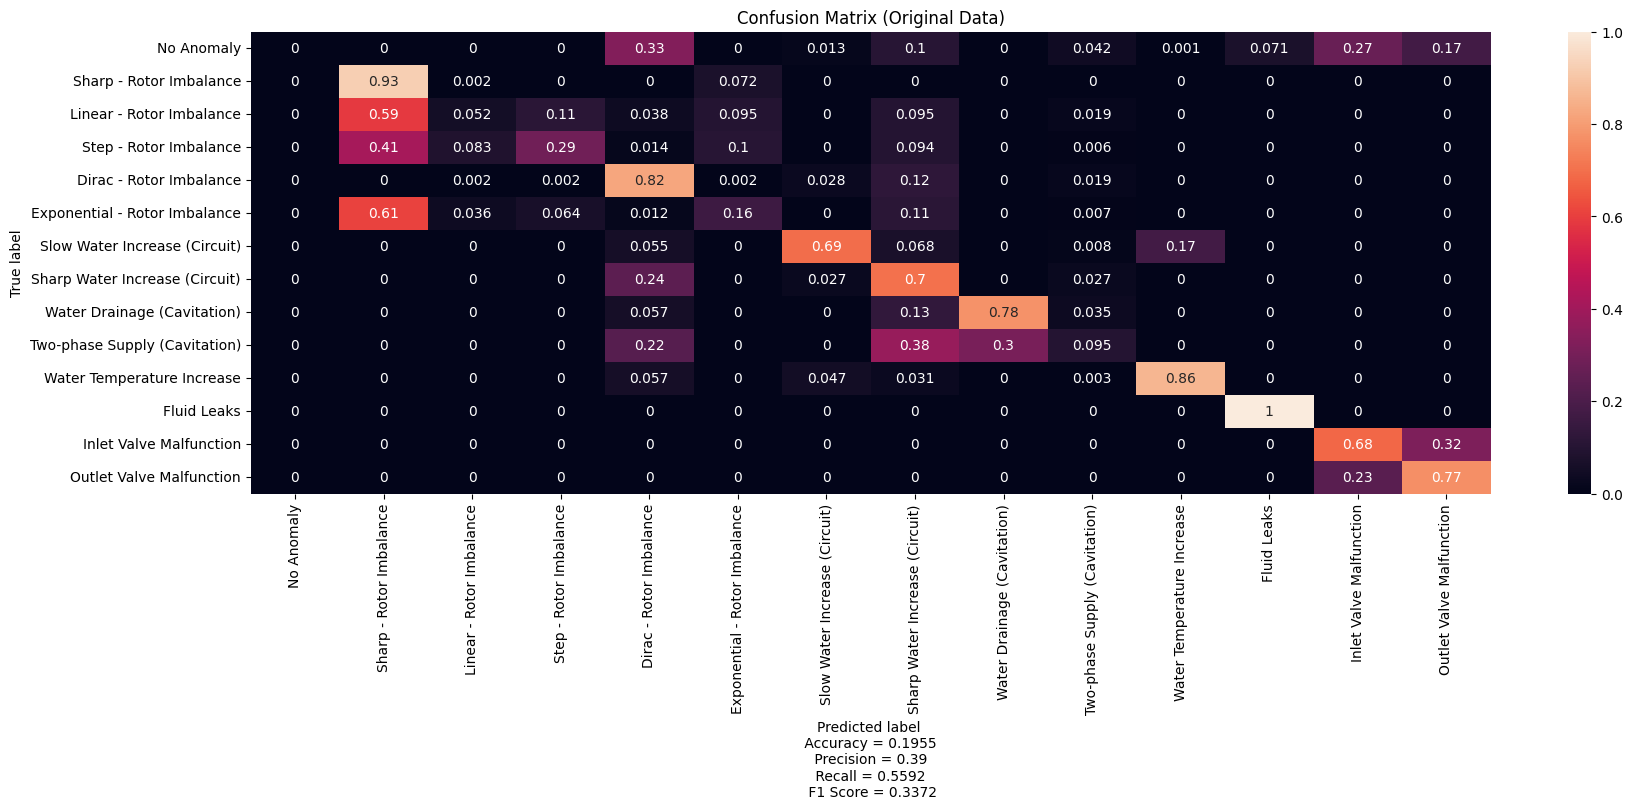

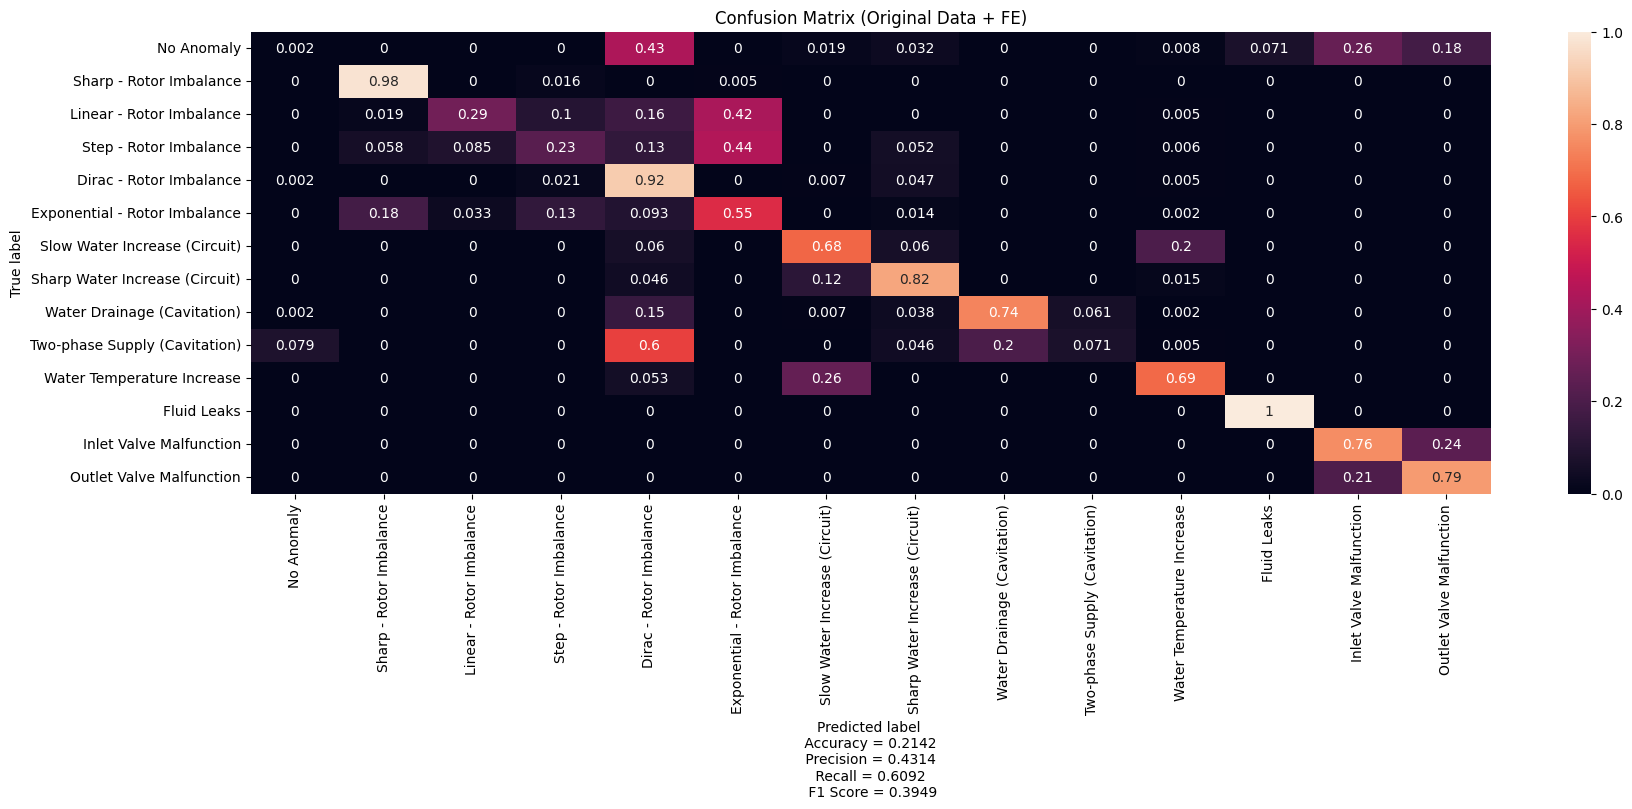

In [54]:
get_confusion_matrix(dataframe_X_og_pred, anomaly_names, title="Confusion Matrix (Original Data)")
get_confusion_matrix(dataframe_X_og_fe_pred, anomaly_names, title="Confusion Matrix (Original Data + FE)")

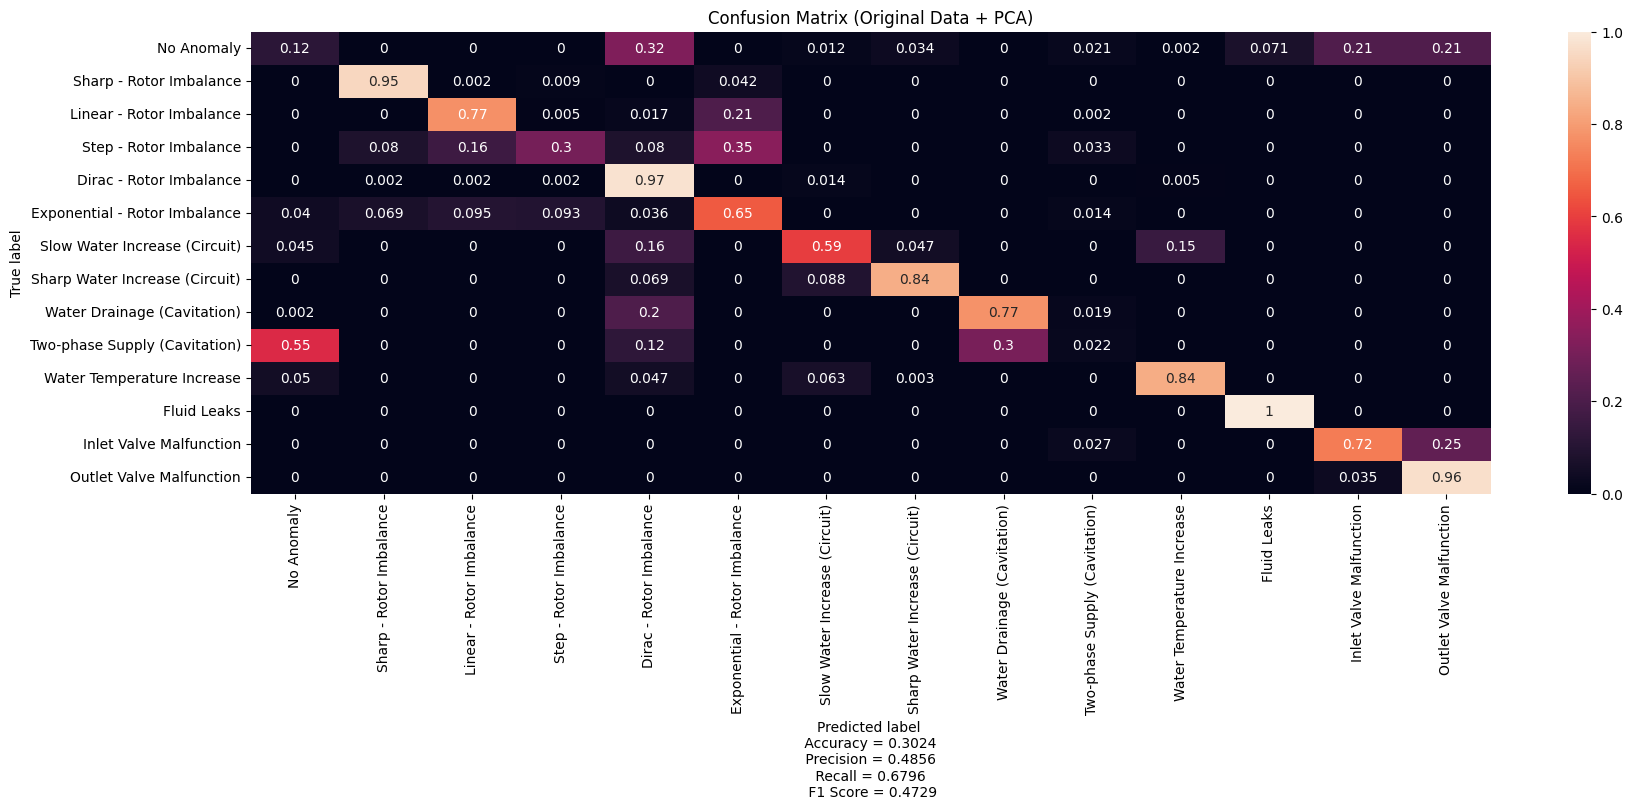

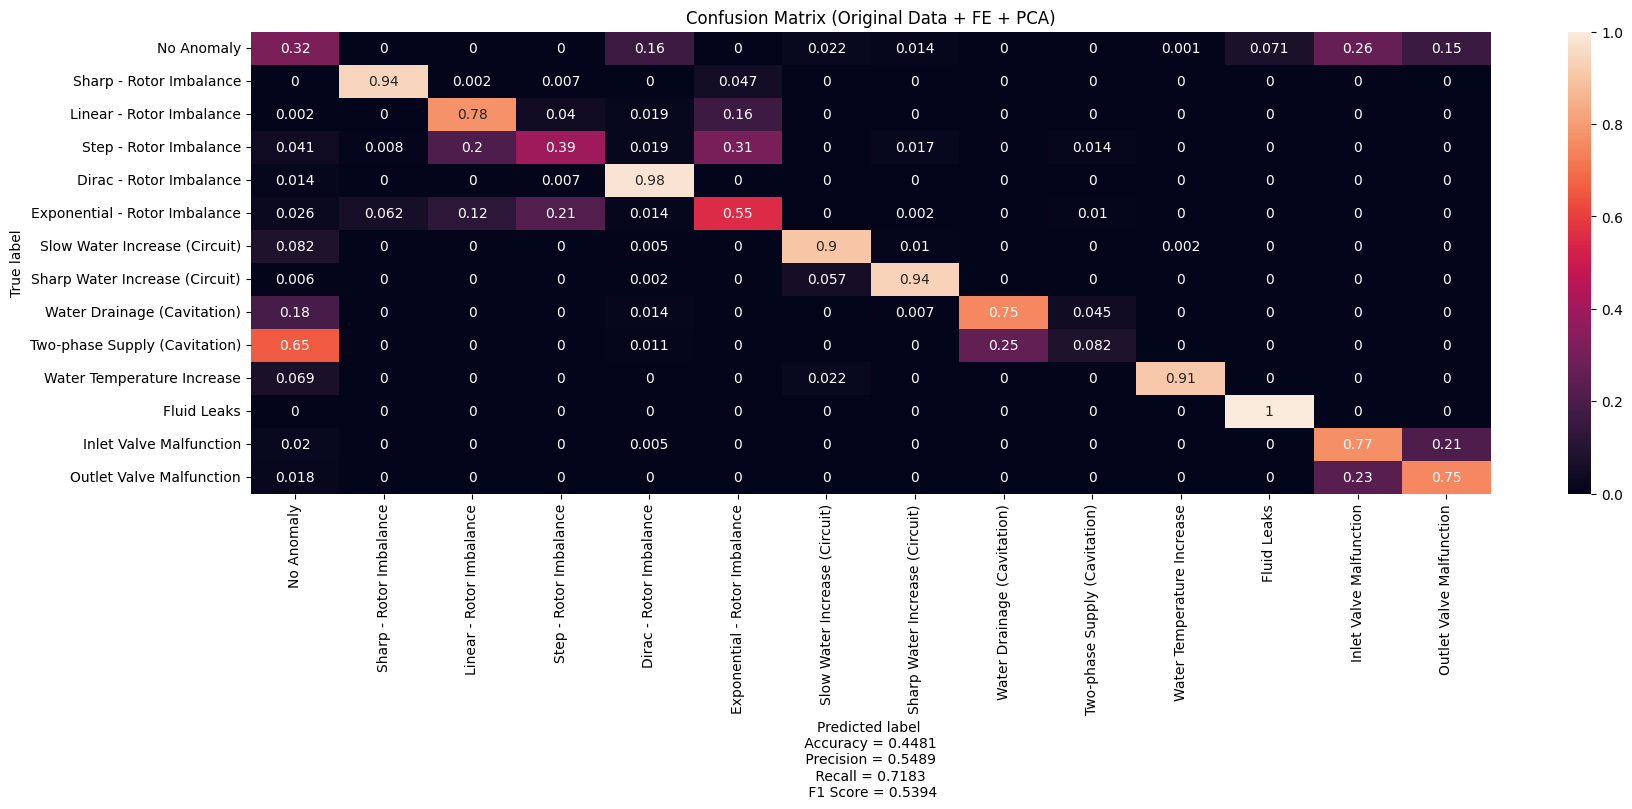

In [55]:
get_confusion_matrix(dataframe_X_og_pca_pred, anomaly_names, title="Confusion Matrix (Original Data + PCA)")
get_confusion_matrix(dataframe_X_og_fe_pca_pred, anomaly_names, title="Confusion Matrix (Original Data + FE + PCA)")

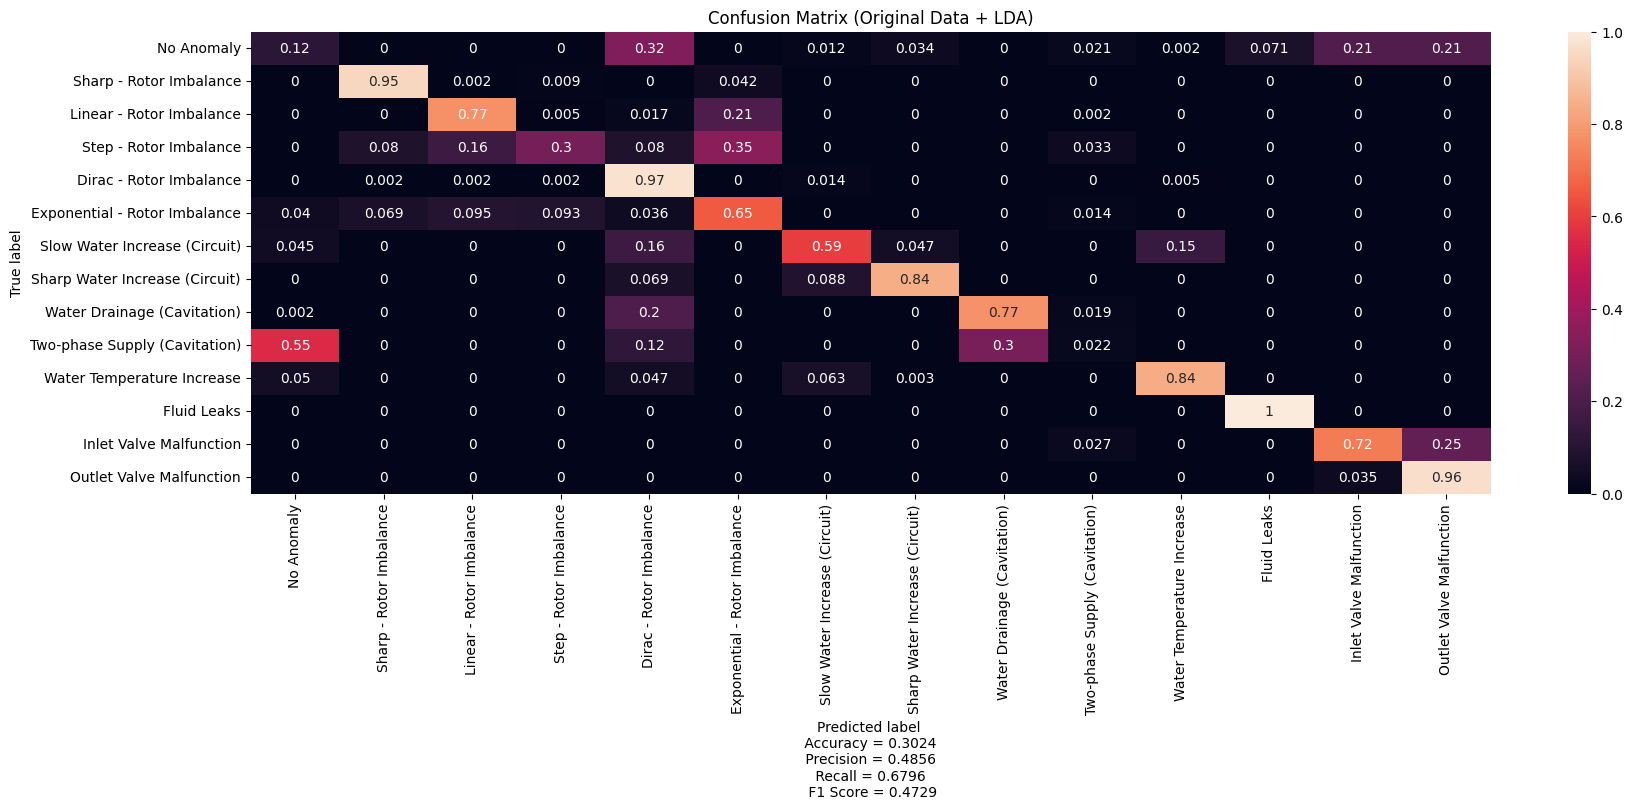

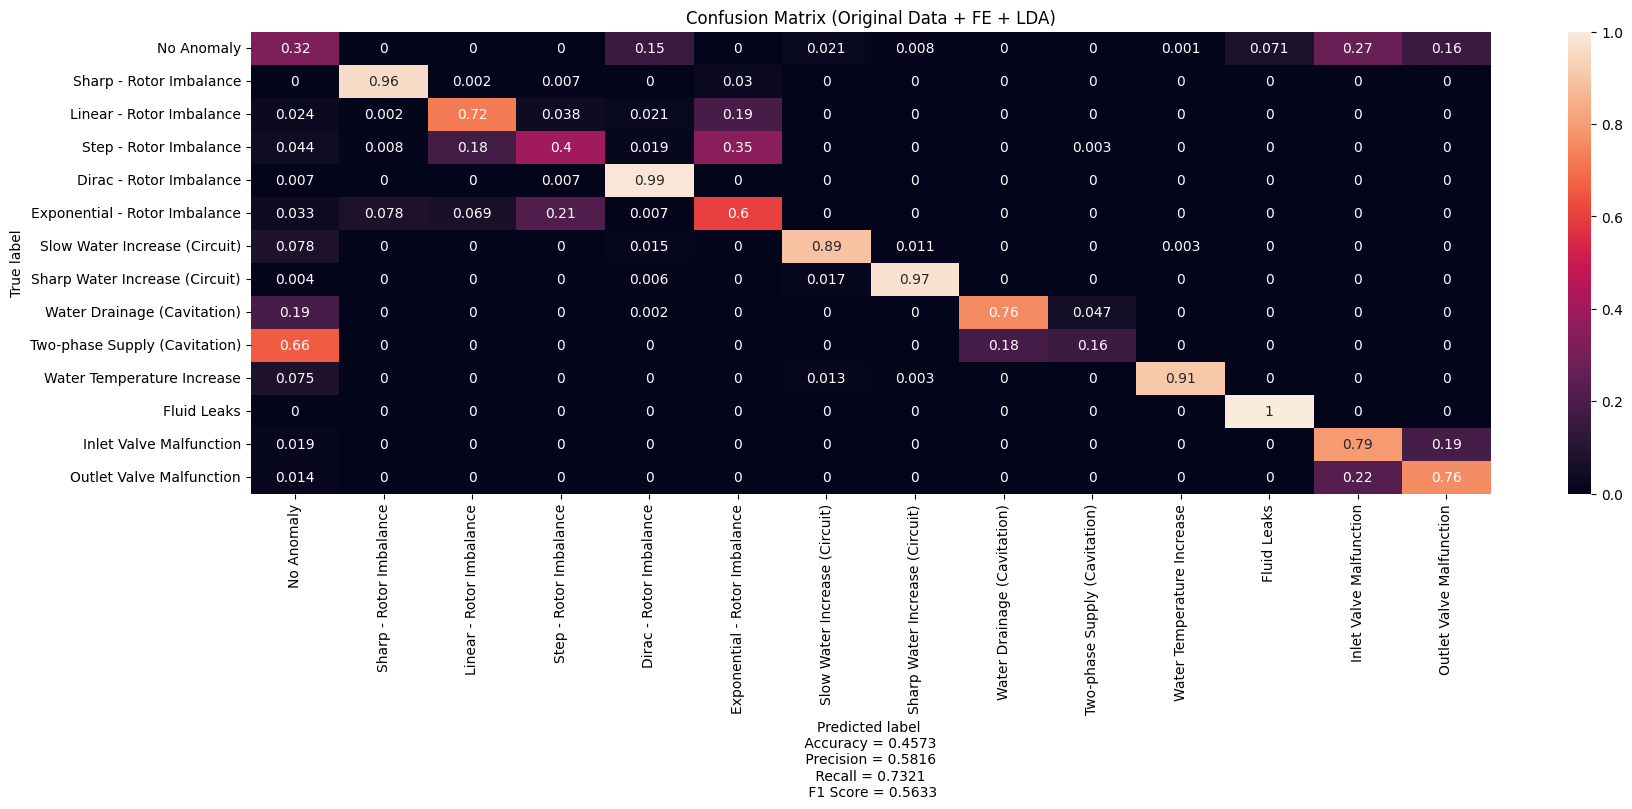

In [56]:
get_confusion_matrix(dataframe_X_og_lda_pred, anomaly_names, title="Confusion Matrix (Original Data + LDA)")
get_confusion_matrix(dataframe_X_og_fe_lda_pred, anomaly_names, title="Confusion Matrix (Original Data + FE + LDA)")

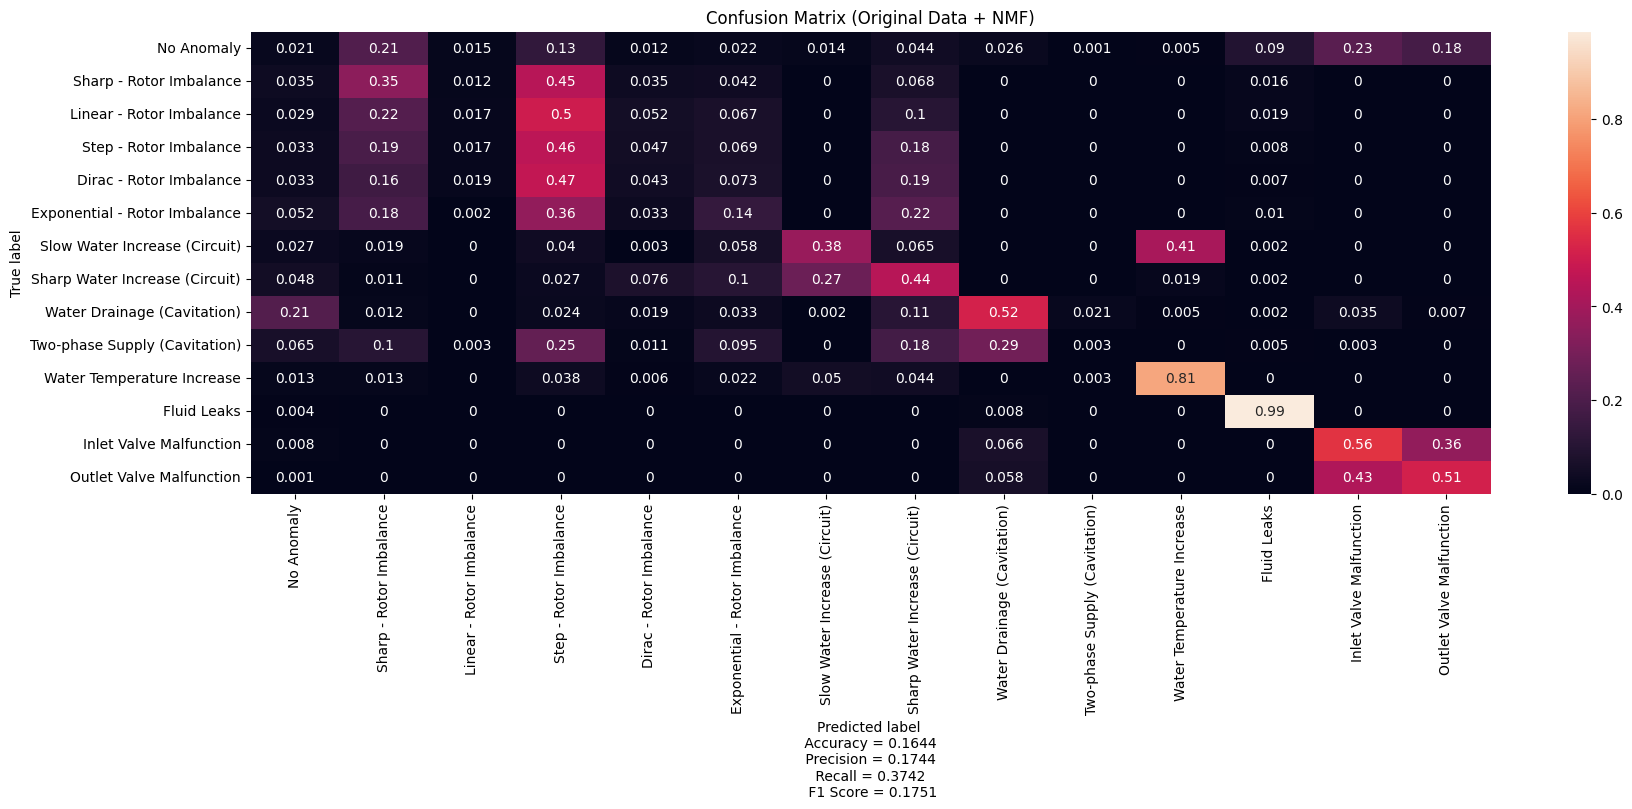

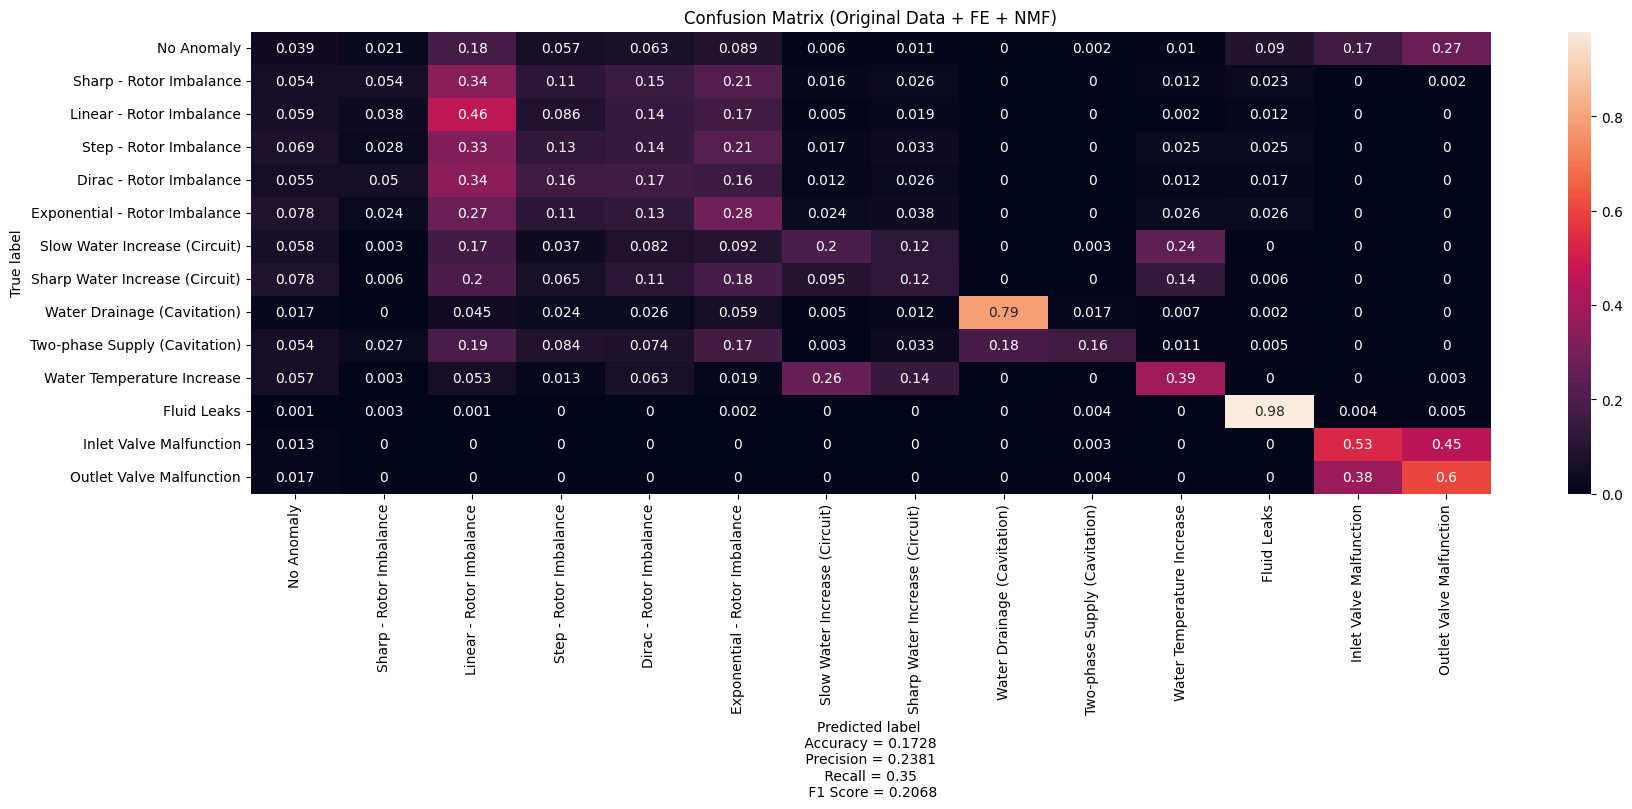

In [57]:
get_confusion_matrix(dataframe_X_og_nmf_pred, anomaly_names, title="Confusion Matrix (Original Data + NMF)")
get_confusion_matrix(dataframe_X_og_fe_nmf_pred, anomaly_names, title="Confusion Matrix (Original Data + FE + NMF)")